# BIG WIP

In [42]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString, MultiLineString
from shapely import wkt
from shapely.ops import unary_union, linemerge, nearest_points
import plotly.express as px
from helper_functions import quick_px_scattermap
import osmnx as ox
import networkx as nx

In [2]:
station_avg_delay = pd.read_csv("../data/processed/cleaned_delay_data.csv")
station_avg_ridership = pd.read_csv("../data/processed/selected_station_ridership.csv")
selected_routes_shapes = pd.read_csv("../data/processed/selected_routes.csv")
sj_adt = pd.read_csv("../data/processed/selected_sj_adt.csv")

selected_routes = ['22', 'Rapid 522', '23', 'Rapid 523', '25', '60']
station_avg_delay = station_avg_delay[station_avg_delay["route_id"].isin(selected_routes)]
station_avg_delay = station_avg_delay.groupby(['route_id', 'direction_id', 'stop_id', 'stop_sequence']).agg(mean_delay=("computed_delay_sec", "mean")).reset_index().sort_values(['route_id', 'direction_id', 'stop_sequence'])
station_avg_delay["route_id"] = station_avg_delay["route_id"].str.replace(
    r"^Rapid\s+", "", regex=True
).astype(int)
station_avg_delay

,route_id,direction_id,stop_id,stop_sequence,mean_delay
18,22,0,60328,2,139.500000
19,22,0,60329,3,196.000000
20,22,0,60330,4,173.000000
21,22,0,60331,5,146.500000
22,22,0,60332,6,158.666667
...,...,...,...,...,...
586,523,1,60651,13,-466.000000
587,523,1,60653,14,-488.500000
588,523,1,60656,15,-525.000000
589,523,1,60660,16,-604.500000


In [3]:
station_avg_ridership['direction_id'] = station_avg_ridership['direction_id'] % 10
station_avg_ridership = station_avg_ridership.sort_values(['route_id', 'direction_id', 'stop_id'])
station_avg_ridership

,route_id,direction_id,stop_id,stop_name,boardings,alightings,total_b_a,geometry
0,22,0,60001,Santa Clara Transit Center,152.880022,110.852250,263.732272,POINT (6144099.62758 1954225.5200159)
4,22,0,60020,El Camino & Lafayette,40.890986,57.438087,98.329073,POINT (6141651.00288408 1954992.24617273)
6,22,0,60035,King & Alum Rock,149.607974,157.936236,307.544210,POINT (6167727.93202934 1953654.17929506)
7,22,0,60036,King & San Antonio,36.418456,38.469837,74.888293,POINT (6168552.89461824 1952565.84026439)
8,22,0,60037,King & Hermocilla,31.495157,45.198273,76.693430,POINT (6169311.51383591 1951509.07203673)
...,...,...,...,...,...,...,...,...
586,523,1,64478,Lockheed Martin Transit Center,0.000000,317.466630,317.466630,POINT (6117801.90097608 1975568.38743506)
601,523,1,64696,Stevens Creek & Winchester,85.577443,90.755989,176.333432,POINT (6139677.16759291 1943518.2914304)
620,523,1,65741,Stevens Creek & Valley Fair / Santana Row,109.060532,391.806776,500.867308,POINT (6141126.594156 1943538.09191573)
642,523,1,65902,Sunnyvale-Saratoga & El Camino,189.107898,219.736022,408.843920,POINT (6116423.22131875 1959757.18710214)


In [47]:
def safe_wkt_load(x):
    if pd.isna(x):
        return None
    return wkt.loads(x)

stations_df = pd.merge(station_avg_delay, station_avg_ridership, on=['route_id', 'direction_id', 'stop_id'], how='inner')
stations_df["geometry"] = stations_df["geometry"].apply(safe_wkt_load)
stations_gdf = gpd.GeoDataFrame(stations_df, geometry='geometry', crs="EPSG:2227").sort_values(["route_id", "direction_id", "stop_sequence"])
stations_gdf

,route_id,direction_id,stop_id,stop_sequence,mean_delay,stop_name,boardings,alightings,total_b_a,geometry
0,22,0,60328,2,139.500000,Palo Alto Transit Center (Bay 10),733.994859,0.238095,734.176677,POINT (6078107.96 1988346.454)
1,22,0,60329,3,196.000000,El Camino & Palm,12.793264,3.426027,16.219290,POINT (6079055.872 1986640.972)
2,22,0,60330,4,173.000000,El Camino & Galvez,66.459791,7.428228,73.888019,POINT (6079788.226 1985807.876)
3,22,0,60331,5,146.500000,El Camino & Sam McDonald,4.579660,0.262500,4.842160,POINT (6080518.117 1984980.671)
4,22,0,60332,6,158.666667,El Camino & Churchill,4.251791,1.055649,5.307440,POINT (6081284.46 1984093.848)
...,...,...,...,...,...,...,...,...,...,...
568,523,1,60646,12,-410.000000,Stevens Creek & Kiely,131.524218,172.415548,303.939766,POINT (6132531.454 1943566.328)
569,523,1,60651,13,-466.000000,Stevens Creek & Cabot,52.817891,62.395022,115.212913,POINT (6127904.459 1943613.843)
570,523,1,60656,15,-525.000000,Stevens Creek & Wolfe,66.990445,88.557801,155.548246,POINT (6121122.696 1943673.642)
571,523,1,60660,16,-604.500000,Stevens Creek & De Anza,85.345256,218.676593,304.021849,POINT (6115865.544 1943743.247)


In [43]:
G = ox.graph_from_place("Santa Clara County, California, USA", network_type="drive")
G = ox.project_graph(G, to_crs="EPSG:2227")

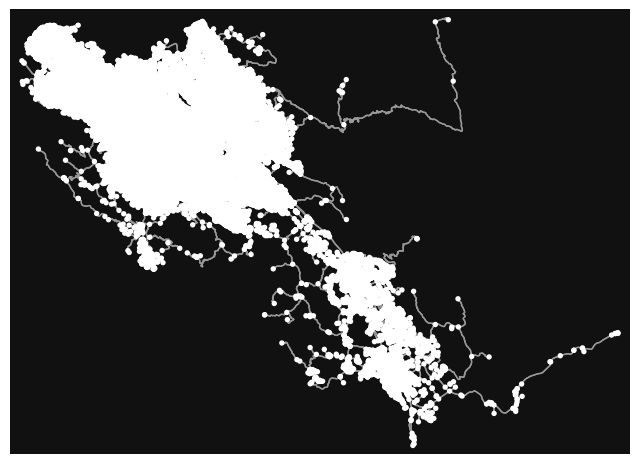

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [53]:
ox.plot_graph(G)

In [48]:
stations_gdf = stations_gdf.to_crs(G.graph["crs"])

nodes = ox.distance.nearest_nodes(
    G,
    X=stations_gdf.geometry.x,
    Y=stations_gdf.geometry.y
)

stations_gdf["node"] = nodes
stations_gdf

,route_id,direction_id,stop_id,stop_sequence,mean_delay,stop_name,boardings,alightings,total_b_a,geometry,node
0,22,0,60328,2,139.500000,Palo Alto Transit Center (Bay 10),733.994859,0.238095,734.176677,POINT (6078107.96 1988346.454),868564168
1,22,0,60329,3,196.000000,El Camino & Palm,12.793264,3.426027,16.219290,POINT (6079055.872 1986640.972),6067350538
2,22,0,60330,4,173.000000,El Camino & Galvez,66.459791,7.428228,73.888019,POINT (6079788.226 1985807.876),1819712513
3,22,0,60331,5,146.500000,El Camino & Sam McDonald,4.579660,0.262500,4.842160,POINT (6080518.117 1984980.671),65518519
4,22,0,60332,6,158.666667,El Camino & Churchill,4.251791,1.055649,5.307440,POINT (6081284.46 1984093.848),6067033560
...,...,...,...,...,...,...,...,...,...,...,...
568,523,1,60646,12,-410.000000,Stevens Creek & Kiely,131.524218,172.415548,303.939766,POINT (6132531.454 1943566.328),2404195087
569,523,1,60651,13,-466.000000,Stevens Creek & Cabot,52.817891,62.395022,115.212913,POINT (6127904.459 1943613.843),262982776
570,523,1,60656,15,-525.000000,Stevens Creek & Wolfe,66.990445,88.557801,155.548246,POINT (6121122.696 1943673.642),306087834
571,523,1,60660,16,-604.500000,Stevens Creek & De Anza,85.345256,218.676593,304.021849,POINT (6115865.544 1943743.247),65426566


In [56]:
def compute_osm_spacing(stations_gdf):
    results = []

    for (route_id, direction_id), stops in stations_gdf.groupby(["route_id", "direction_id"]):

        stops = stops.sort_values("stop_sequence").copy()

        spacings = [None]

        for i in range(1, len(stops)):
            n1 = stops.iloc[i - 1]["node"]
            n2 = stops.iloc[i]["node"]

            try:
                dist = nx.shortest_path_length(G, n1, n2, weight="length")
            except:
                dist = None

            spacings.append(dist)

        stops["spacing_ft"] = spacings
        results.append(stops)

    return pd.concat(results, ignore_index=True)

In [ ]:
station_spacings = compute_osm_spacing(stations_gdf)
station_spacings

,route_id,direction_id,stop_id,stop_sequence,mean_delay,stop_name,boardings,alightings,total_b_a,geometry,node,spacing_ft
0,22,0,60328,2,139.500000,Palo Alto Transit Center (Bay 10),733.994859,0.238095,734.176677,POINT (6078107.96 1988346.454),868564168,NaN
1,22,0,60329,3,196.000000,El Camino & Palm,12.793264,3.426027,16.219290,POINT (6079055.872 1986640.972),6067350538,697.200342
2,22,0,60330,4,173.000000,El Camino & Galvez,66.459791,7.428228,73.888019,POINT (6079788.226 1985807.876),1819712513,352.118584
3,22,0,60331,5,146.500000,El Camino & Sam McDonald,4.579660,0.262500,4.842160,POINT (6080518.117 1984980.671),65518519,372.144171
4,22,0,60332,6,158.666667,El Camino & Churchill,4.251791,1.055649,5.307440,POINT (6081284.46 1984093.848),6067033560,309.088220
...,...,...,...,...,...,...,...,...,...,...,...,...
568,523,1,60646,12,-410.000000,Stevens Creek & Kiely,131.524218,172.415548,303.939766,POINT (6132531.454 1943566.328),2404195087,1519.318249
569,523,1,60651,13,-466.000000,Stevens Creek & Cabot,52.817891,62.395022,115.212913,POINT (6127904.459 1943613.843),262982776,1535.552862
570,523,1,60656,15,-525.000000,Stevens Creek & Wolfe,66.990445,88.557801,155.548246,POINT (6121122.696 1943673.642),306087834,2357.018870
571,523,1,60660,16,-604.500000,Stevens Creek & De Anza,85.345256,218.676593,304.021849,POINT (6115865.544 1943743.247),65426566,1716.196417


In [ ]:
fig = quick_px_scattermap(station_spacings,
                          color="spacing_ft",
                          opacity=0.5,
                          hover_data=["route_id", "direction_id", "stop_sequence", "spacing_ft", "total_b_a"],
                          zoom=10,
                          height=650
)
fig.show()

In [62]:
sj_station_adt = station_spacings.copy()
sj_adt

,counter_id,adt,main_road,counter_location,cross_road,nearby_intersect,geometry,index_right,line_id,route_id,route_desc,category,route_length,object_id
0,4450,14432.0,AIRPORT BLVD,S of,SKYPORT DR,AIRPORT BLVD & SKYPORT DR,POINT (6148939.75897583 1958001.95603256),20,23904,60,WINCHESTER STN - MILPITAS BART,Frequent,151256.059019,21
1,4457,8385.0,ALMADEN AVE,N of,WILLOW ST,ALMADEN AVE & WILLOW ST,POINT (6159716.96708016 1941603.89270015),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
2,4469,848.0,BLEWETT AVE,S of,WILLOW ST,BLEWETT AVE & WILLOW ST,POINT (6154536.48826791 1937960.99808306),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
3,4470,936.0,BLEWETTE AVE,S of,WILLOW ST,BLEWETTE AVE & WILLOW ST,POINT (6154536.48826791 1937960.99808306),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
4,4474,45690.0,BROKAW RD,E of,OAKLAND RD,BROKAW RD&OAKLAND RD,POINT (6156171.61984016 1964851.78419639),20,23904,60,WINCHESTER STN - MILPITAS BART,Frequent,151256.059019,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,7251,13221.0,KING RD,S of,OCALA AVE,KING RD & OCALA AVE,POINT (6173723.99155949 1945717.51242565),2,23875,22,PALO ALTO - EASTRIDGE,Frequent,242559.907697,3
490,7261,18169.0,STORY RD,E of,BAL HARBOR WAY,STORY RD & BAL HARBOR WAY,POINT (6172131.01016541 1949785.0761409),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
491,7262,20206.0,STORY RD,E of,JACKSON AVE,STORY RD & JACKSON AVE,POINT (6174397.29205017 1951653.89392556),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
492,7263,21056.0,STORY RD,W of,ROBERTS AVE,STORY RD & ROBERTS AVE,POINT (6166346.74647149 1945014.70215148),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
